# Signal Processing in Practice Laboratory
## Assignment 1: Array Signal Processing


### 📋 Rubric (Total: 50 Points)

| Task/Question | Description | Points |
|---|---|---|
| Task 1 | Steering vector `gen_a()` | 5 |
| Task 2 | Spatial response `spat_response()` | 5 |
| Task 3 | Data matrix `gen_data()` | 5 |
| Question 1 | Spatial response plots + analysis | 10 |
| Question 2 | Singular values & eigenvalues | 10 |
| Question 3 | Matched filter vs ZF beamformer | 8 |
| Question 4 | Classical BF, MVDR, MUSIC | 7 |
| **Total** | | **50** |

---

### Submission Instructions
- Fill in your **Name** and **SR Number** in the cell below.
- Answer theoretical questions in **text (Markdown) cells** using LaTeX for equations.
- All code cells must **run without errors** — do **not** erase outputs before submission.
- Share the Colab link in Teams as instructed.

In [1]:
# ✏️ Fill in your details
# Name: Dwaipayan Haldar
# SR Number: 04-03-01-10-42-25-1-27128

In [2]:
import numpy as np
from matplotlib import pyplot as plt

# Add any other imports you need here
np.random.seed(42)   # for reproducibility — keep this line

---
## Task 1 — Steering Vector  *(5 points)*

Implement `gen_a(M, Delta, theta)` that returns the **ULA array steering vector**:

$$
{\bf a}(\theta) = \left[1,\; e^{j 2\pi\Delta\sin\theta},\; e^{j 4\pi\Delta\sin\theta},\; \ldots,\; e^{j 2\pi\Delta(M-1)\sin\theta}\right]^T \in \mathbb{C}^{M\times 1}
$$

**Parameters:**
- `M` — number of antenna elements  
- `Delta` — inter-element spacing in wavelengths  
- `theta` — angle of arrival **in degrees**  

**Returns:** complex column vector of shape `(M, 1)`

>  **Hint:** Use `np.arange` for the element indices and remember to convert degrees to radians.

In [3]:
def gen_a(M, Delta, theta):
    """
    Generate the ULA steering vector.

    Parameters
    ----------
    M     : int   — number of antenna elements
    Delta : float — element spacing in wavelengths
    theta : float — angle of arrival in degrees

    Returns
    -------
    a : np.ndarray, shape (M, 1), dtype complex
    """
    # ---- YOUR CODE HERE ----
    m = np.arange(M)                        # element indices 0, 1, ..., M-1
    theta_rad = np.deg2rad(theta)           # convert degrees to radians
    a = np.exp(1j * 2 * np.pi * Delta * np.sin(theta_rad) * m)
    return a.reshape(M, 1)
    # ---- END YOUR CODE ----


# ── Quick sanity check (do not modify) ──────────────────────
a = gen_a(4, 0.5, 0)
assert a is not None, "gen_a returned None — did you forget 'return'?"
assert a.shape == (4, 1), f"Expected shape (4,1), got {a.shape}"
assert np.allclose(np.abs(a), 1), "All entries should have unit magnitude"
assert np.isclose(a[0, 0], 1.0), "First element should be 1"
print("Task 1 checks passed!")

Task 1 checks passed!


---
## Task 2 — Spatial Response  *(5 points)*

Implement `spat_response(w, Delta, theta_range)` that computes:

$$
|y(\theta)| = |{\bf w}^H {\bf a}(\theta)|, \quad \theta \in \boldsymbol{\theta}_{\text{range}}
$$

**Parameters:**
- `w` — beamformer weight vector, shape `(M, 1)` or `(M,)`
- `Delta` — element spacing in wavelengths  
- `theta_range` — 1-D array of angles **in degrees** to evaluate  

**Returns:** real-valued 1-D array of length `len(theta_range)`

> **Hint:** The superscript $H$ denotes the **conjugate transpose**. In NumPy, `.conj().T` or `np.conj(w).T` gives you that.

In [4]:
def spat_response(w, Delta, theta_range):
    """
    Compute the spatial response |w^H a(theta)| over a range of angles.

    Parameters
    ----------
    w           : array-like, shape (M,) or (M, 1)
    Delta       : float — element spacing in wavelengths
    theta_range : 1-D array of angles in degrees

    Returns
    -------
    y : np.ndarray, shape (len(theta_range),), real-valued
    """
    w = np.array(w).reshape(-1, 1)   # ensure column vector
    M = len(w)
    y = np.zeros(len(theta_range))

    # ---- YOUR CODE HERE ----
    for i, theta in enumerate(theta_range):
        a = gen_a(M, Delta, theta)           # (M, 1)
        y[i] = np.abs(w.conj().T @ a)[0, 0] # |w^H a(theta)|
    # ---- END YOUR CODE ----

    return y


# ── Quick sanity check (do not modify) ──────────────────────
w_test = np.ones((4, 1))
theta_test = np.array([0.0, 30.0, 90.0])
y_test = spat_response(w_test, 0.5, theta_test)
assert y_test.shape == (3,), f"Expected shape (3,), got {y_test.shape}"
assert np.isclose(y_test[0], 4.0), f"At theta=0 with M=4 ones, expected 4.0, got {y_test[0]:.4f}"
print("Task 2 checks passed!")

Task 2 checks passed!


---
## Task 3 — Data Matrix Generator  *(5 points)*

Implement `gen_data(M, N, Delta, theta, SNR_dB)` to generate the array observation model:

$$
{\bf X} = {\bf A}_{\theta}\,{\bf S} + {\bf N} \;\in\; \mathbb{C}^{M \times N}
$$

where $\mathbf{A}_\theta = [\mathbf{a}(\theta_1),\ldots,\mathbf{a}(\theta_d)] \in \mathbb{C}^{M\times d}$.

**Signal model:**
- Source symbols $\mathbf{S} \in \mathbb{C}^{d\times N}$: drawn uniformly from QPSK alphabet $\{(\pm 1 \pm j)/\sqrt{2}\}$  
- Noise $\mathbf{N}$: i.i.d. $\mathcal{CN}(0, \sigma^2)$, where $\sigma^2 = 10^{-\text{SNR}_{\text{dB}}/10}$ (assuming unit source power)

**Parameters:**
- `theta` — list/array of DOAs in degrees  

**Returns:** `X` (M×N), `A` (M×d), `S` (d×N)

In [5]:
def gen_data(M, N, Delta, theta, SNR_dB):
    """
    Generate the array data matrix X = A*S + N.

    Parameters
    ----------
    M      : int   — number of antennas
    N      : int   — number of snapshots
    Delta  : float — element spacing in wavelengths
    theta  : list/array of DOAs in degrees, length d
    SNR_dB : float — signal-to-noise ratio in dB

    Returns
    -------
    X : np.ndarray, shape (M, N) — observed data
    A : np.ndarray, shape (M, d) — array manifold matrix
    S : np.ndarray, shape (d, N) — transmitted symbols
    """
    theta = np.array(theta)
    d = len(theta)

    # ── Build A (M x d) ─────────────────────────────────────
    A = np.hstack([gen_a(M, Delta, th) for th in theta])   # (M, d)

    # ── Generate QPSK symbols S (d x N) ─────────────────────
    alphabet = np.array([1+1j, 1-1j, -1+1j, -1-1j]) / np.sqrt(2)
    S = np.random.choice(alphabet, size=(d, N))             # (d, N)

    # ── Generate complex Gaussian noise N (M x N) ───────────
    sigma2 = 10 ** (-SNR_dB / 10)  # noise variance (unit source power assumed)
    noise = np.sqrt(sigma2 / 2) * (np.random.randn(M, N) + 1j * np.random.randn(M, N))

    # ---- YOUR CODE HERE ----
    X = A @ S + noise
    # ---- END YOUR CODE ----

    return X, A, S


# ── Quick sanity check (do not modify) ──────────────────────
X_t, A_t, S_t = gen_data(7, 100, 0.5, [0, 30], 10)
assert X_t.shape == (7, 100), f"X shape: expected (7,100), got {X_t.shape}"
assert A_t.shape == (7,  2),  f"A shape: expected (7,2),   got {A_t.shape}"
assert S_t.shape == (2, 100), f"S shape: expected (2,100), got {S_t.shape}"
assert np.iscomplexobj(X_t),  "X should be complex"
print("Task 3 checks passed!")

Task 3 checks passed!


---
## Question 1 — Beampattern Analysis  *(10 points)*

Use the all-ones beamformer $\mathbf{w} = [1,1,\ldots,1]^T$ (Delay-and-Sum / conventional BF).

### Part A *(5 pts)*
Fix $\Delta = 0.5$ and plot the spatial response $|y(\theta)|$ for $M \in \{2, 4, 7\}$ on the **same axes**.

### Part B *(5 pts)*
Fix $M = 7$ and plot the spatial response for $\Delta \in \{0.5, 1.0, 2.0\}$ on the **same axes**.

---
**For each plot:** sweep $\theta \in [-90°, 90°]$, label axes, add a legend, and include a title.

**Written answer required:** In the Markdown cell below the plots, answer:
1. How does increasing $M$ affect the beamwidth and sidelobe level?
2. What happens when $\Delta > 0.5$? What is this phenomenon called, and why is it problematic?
3. What is the standard choice of $\Delta$ and why?

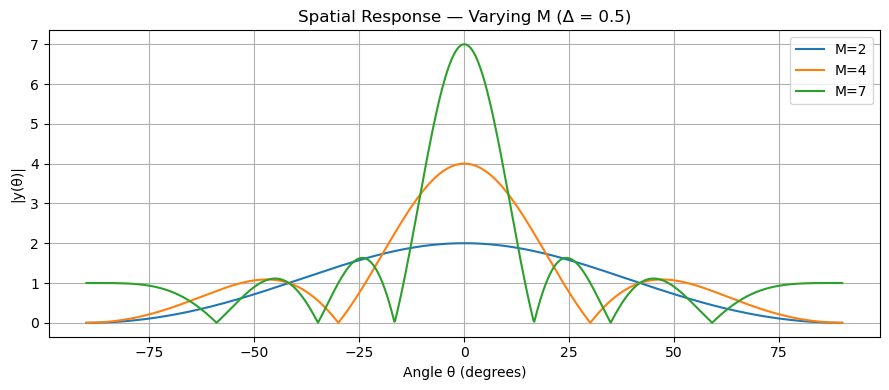

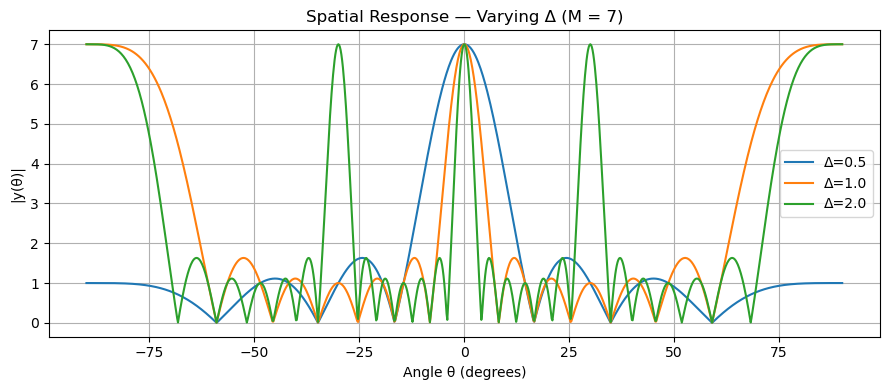

In [6]:
# ── Q1 Code ─────────────────────────────────────────────────
theta_range = np.linspace(-90, 90, 1000)
Delta_fixed = 0.5

# --- Part A: vary M, fix Delta = 0.5 ---
fig, ax = plt.subplots(figsize=(9, 4))

# ---- YOUR CODE HERE ----
for M_val in [2, 4, 7]:
    w = np.ones((M_val, 1))
    y = spat_response(w, Delta_fixed, theta_range)
    ax.plot(theta_range, y, label=f'M={M_val}')
# ---- END YOUR CODE ----

ax.set_xlabel('Angle θ (degrees)')
ax.set_ylabel('|y(θ)|')
ax.set_title('Spatial Response — Varying M (Δ = 0.5)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

# --- Part B: vary Delta, fix M = 7 ---
fig, ax = plt.subplots(figsize=(9, 4))
M_fixed = 7

# ---- YOUR CODE HERE ----
for Delta_val in [0.5, 1.0, 2.0]:
    w = np.ones((M_fixed, 1))
    y = spat_response(w, Delta_val, theta_range)
    ax.plot(theta_range, y, label=f'Δ={Delta_val}')
# ---- END YOUR CODE ----

ax.set_xlabel('Angle θ (degrees)')
ax.set_ylabel('|y(θ)|')
ax.set_title('Spatial Response — Varying Δ (M = 7)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

### Q1 Written Answer

*Double-click this cell and replace the placeholders with your observations.*

**Effect of increasing M:**  
> *Your answer here.*

**Effect of Δ > 0.5 (what is the phenomenon?):**  
> *Your answer here.*

**Standard choice of Δ and reasoning:**  
> *Your answer here.*

---
## Question 2 — Singular Values & Eigenvalues  *(10 points)*

Investigate the structure of $\mathbf{X}$ through its singular values and the eigenvalues of the sample covariance matrix $\hat{\mathbf{R}}_x = \frac{1}{N}\mathbf{X}\mathbf{X}^H$.

Consider two sources. For each of the 8 parameter combinations below, plot the **singular values** of $\mathbf{X}$ and the **eigenvalues** of $\hat{\mathbf{R}}_x$ (in descending order):

| | DOA separation | M | N | SNR (dB) |
|---|---|---|---|---|
| A | 5° (sources at 0°, 5°) | 7 | 20 | 0 |
| B | 5° | 7 | 100 | 0 |
| C | 5° | 20 | 20 | 0 |
| D | 5° | 7 | 20 | 20 |
| E | 60° (sources at 0°, 60°) | 7 | 20 | 0 |
| F | 60° | 7 | 100 | 0 |
| G | 60° | 20 | 20 | 0 |
| H | 60° | 7 | 20 | 20 |

Organise your plots in a **2×4 grid** (rows = separation, columns = parameter variant). Then answer the questions below.

>  **Hint:** Use `np.linalg.svd` for singular values and `np.linalg.eigvalsh` for eigenvalues. Both return values in ascending order by default — you may need to sort/flip.

/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/2666424481.py:30: RuntimeWarning: divide by zero encountered in matmul
  R_hat = X @ X.conj().T / N
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/2666424481.py:30: RuntimeWarning: overflow encountered in matmul
  R_hat = X @ X.conj().T / N
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/2666424481.py:30: RuntimeWarning: invalid value encountered in matmul
  R_hat = X @ X.conj().T / N


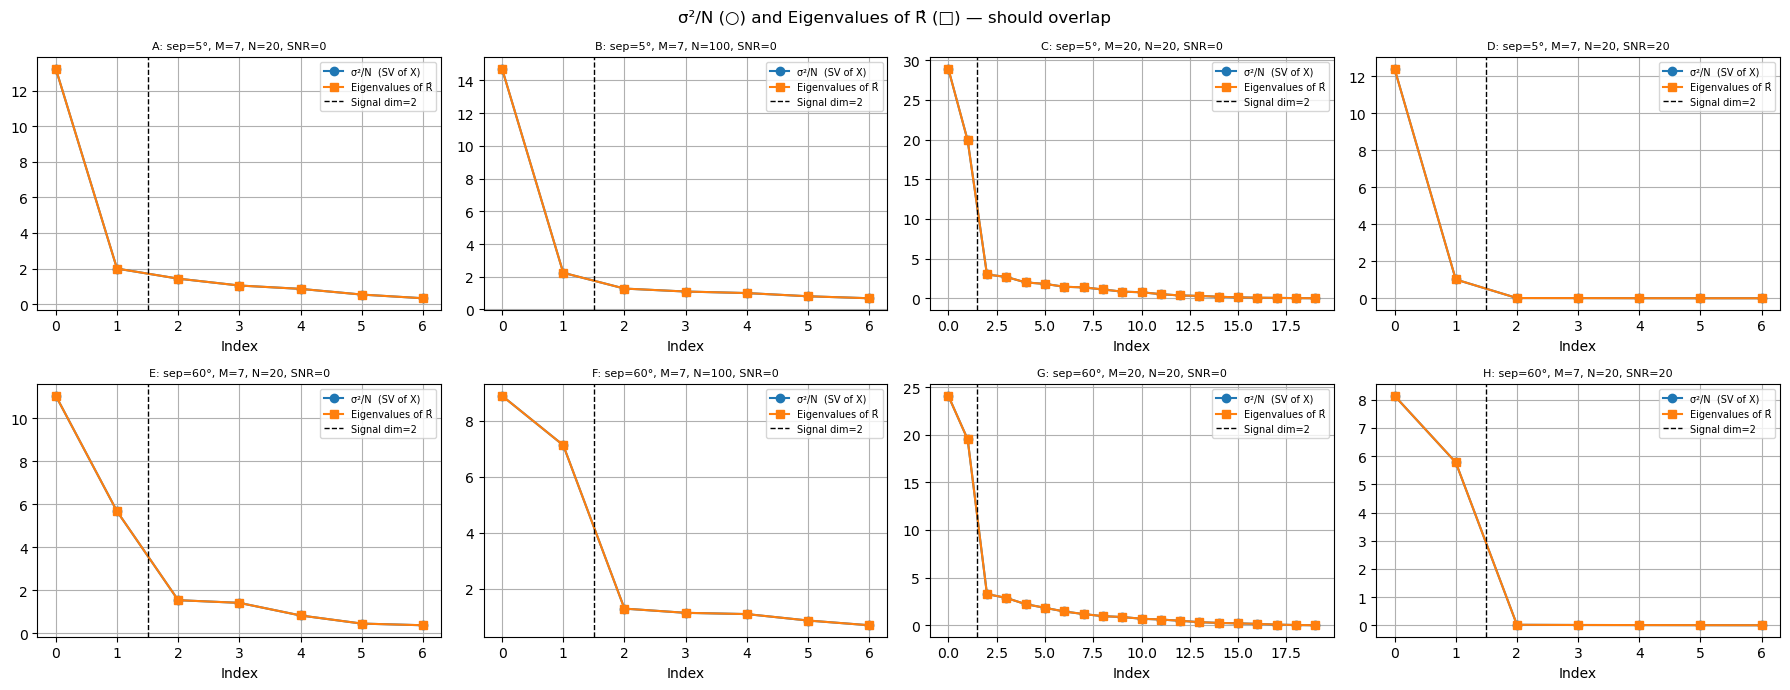

In [7]:
# ── Q2 Code ─────────────────────────────────────────────────
Delta = 0.5
configs = [
    # (label, theta_list, M, N, SNR_dB)
    ('A: sep=5°, M=7, N=20, SNR=0',   [0, 5],  7,  20,  0),
    ('B: sep=5°, M=7, N=100, SNR=0',  [0, 5],  7, 100,  0),
    ('C: sep=5°, M=20, N=20, SNR=0',  [0, 5], 20,  20,  0),
    ('D: sep=5°, M=7, N=20, SNR=20',  [0, 5],  7,  20, 20),
    ('E: sep=60°, M=7, N=20, SNR=0',  [0,60],  7,  20,  0),
    ('F: sep=60°, M=7, N=100, SNR=0', [0,60],  7, 100,  0),
    ('G: sep=60°, M=20, N=20, SNR=0', [0,60], 20,  20,  0),
    ('H: sep=60°, M=7, N=20, SNR=20', [0,60],  7,  20, 20),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for idx, (label, theta, M, N, SNR_dB) in enumerate(configs):
    X, A, S = gen_data(M, N, Delta, theta, SNR_dB)
    ax = axes[idx]
    d = 2  # number of sources

    # ---- YOUR CODE HERE ----
    # Singular values of X — scale as sv²/N so they match eigenvalues of R_hat
    # (R_hat = X X^H / N  =>  eigenvalues = σ_i² / N)
    sv = np.linalg.svd(X, compute_uv=False)
    sv_scaled = sv ** 2 / N   # now on the same scale as eigenvalues of R_hat

    # Eigenvalues of R_hat (eigvalsh returns ascending → flip to descending)
    R_hat = X @ X.conj().T / N
    eigvals = np.linalg.eigvalsh(R_hat)[::-1]

    ax.plot(sv_scaled, 'o-', label='σ²/N  (SV of X)')
    ax.plot(eigvals,   's-', label='Eigenvalues of R̂')
    ax.axvline(d - 0.5, color='k', ls='--', lw=1, label=f'Signal dim={d}')
    # ---- END YOUR CODE ----

    ax.set_title(label, fontsize=8)
    ax.set_xlabel('Index')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('σ²/N (○) and Eigenvalues of R̂ (□) — should overlap', fontsize=12)
plt.tight_layout(); plt.show()

### Q2 Written Answer

*Answer the following based on your plots.*

**1. Relationship between singular values of X and eigenvalues of R̂ₓ:**  
> *Your answer here (include the mathematical relationship).*

**2. How many large singular values/eigenvalues do you expect for d=2 sources? Do your plots confirm this?**  
> *Your answer here.*

**3. Effect of DOA separation (5° vs 60°) on the singular value gap:**  
> *Your answer here.*

**4. Effect of N, M, and SNR on the signal/noise subspace separation:**  
> *Your answer here.*

---
## Question 3 — Matched Filter vs. Zero-Forcing  *(8 points)*

Consider two sources with $\boldsymbol{\theta} = [0°, 5°]^T$, $M=5$, $\Delta=0.5$, $N=1000$.

Assume $\mathbf{A}_\theta$ and $\sigma^2$ are **known** (genie-aided). Implement two beamformers:

| Beamformer | Weight matrix $\mathbf{W}^H$    | Description |
|---|---|---|
| **Matched Filter (MF)** | $\mathbf{W}^H = \mathbf{A}$ | Maximises desired signal power |
| **Zero-Forcing (ZF)** | $\mathbf{W}^H = \mathbf{A}^\dagger =
(\mathbf{A}^H\mathbf{A})^{-1}\mathbf{A}^H$     | Nulls interference |

For each beamformer, the estimated symbols are $\hat{\mathbf{S}} = \mathbf{W}^H \mathbf{X}$.

**Tasks:**
1. *(4 pts)* For SNR ∈ {-5, 0, 10, 20} dB, plot **scatter plots** (Re vs Im) of the first source's estimated symbols. Arrange in a 2×4 grid (rows = MF/ZF, columns = SNR).
2. *(2 pts)* Repeat for $\boldsymbol{\theta} = [0°, 60°]^T$ and comment on the differences.
3. *(2 pts)* Written analysis: which beamformer performs better in each scenario and why?

>  **Hint:** `np.linalg.pinv(A)` gives the Moore-Penrose pseudoinverse $\mathbf{A}^\dagger$.

/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/168383623.py:34: RuntimeWarning: divide by zero encountered in matmul
  X = A @ S + noise
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/168383623.py:34: RuntimeWarning: overflow encountered in matmul
  X = A @ S + noise
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/168383623.py:34: RuntimeWarning: invalid value encountered in matmul
  X = A @ S + noise
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/4280497500.py:16: RuntimeWarning: divide by zero encountered in matmul
  S_hat_mf = A.conj().T @ X / M     # (d, N), unit-gain normalised
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/4280497500.py:16: RuntimeWarning: overflow encountered in matmul
  S_hat_mf = A.conj().T @ X / M     # (d, N), unit-gain normalised
/var/folders/lp/166gmbq56sb3m0xjhm19215w0000gn/T/ipykernel_24121/4280497500.py:16: RuntimeWarning: invalid value encountered in matmul
  S_hat

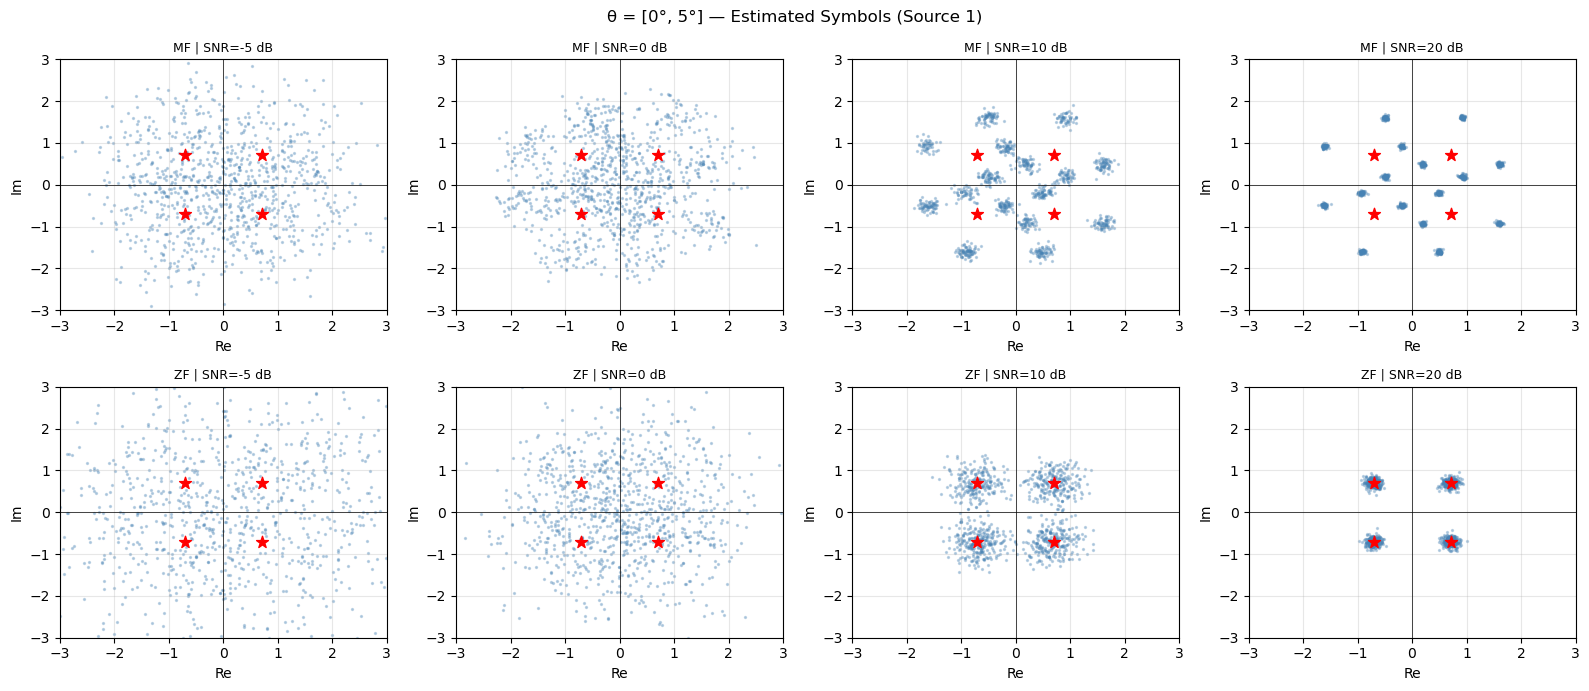

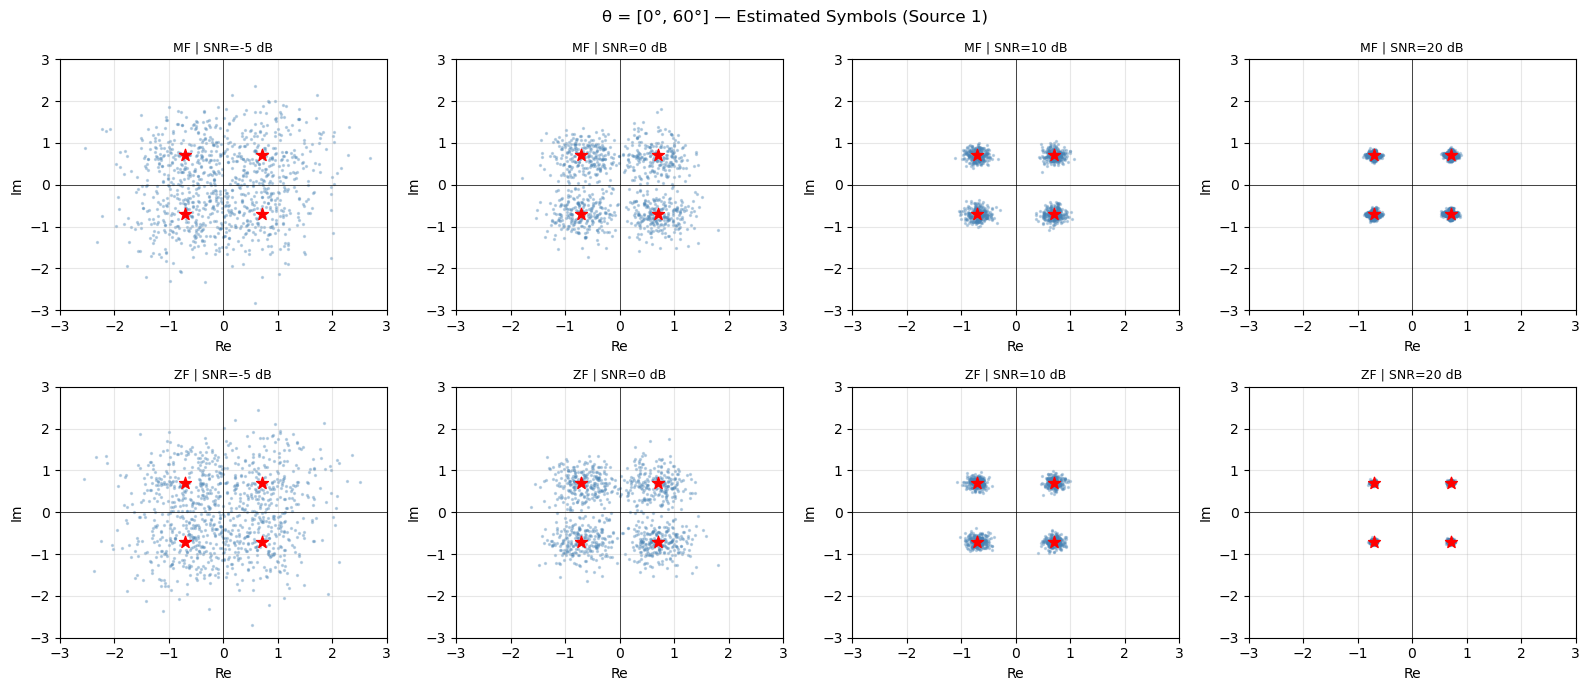

In [8]:
# ── Q3 Code ─────────────────────────────────────────────────
M, N, Delta = 5, 1000, 0.5
snr_values = [-5, 0, 10, 20]

def plot_scatter_grid(theta_list, title_prefix):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    qpsk_ref = np.array([1+1j, 1-1j, -1+1j, -1-1j]) / np.sqrt(2)

    for col, snr in enumerate(snr_values):
        X, A, S = gen_data(M, N, Delta, theta_list, snr)

        # ---- YOUR CODE HERE ----
        # MF: W = A  =>  W^H = A^H.  Divide by M to normalise the array gain
        # (a^H a = M, so without /M the QPSK clusters appear at ±M/√2 ≈ ±3.5,
        #  overflowing the ±3 axis window set by the template).
        S_hat_mf = A.conj().T @ X / M     # (d, N), unit-gain normalised

        # ZF: W^H = pinv(A) — already provides unit gain: pinv(A) @ A = I
        S_hat_zf = np.linalg.pinv(A) @ X  # (d, N)
        # ---- END YOUR CODE ----

        for row, (label, S_hat) in enumerate([('MF', S_hat_mf), ('ZF', S_hat_zf)]):
            ax = axes[row, col]
            ax.scatter(S_hat[0].real, S_hat[0].imag, s=2, alpha=0.3, color='steelblue')
            ax.scatter(qpsk_ref.real, qpsk_ref.imag, s=80, marker='*', color='red', zorder=5)
            ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
            ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
            ax.set_title(f'{label} | SNR={snr} dB', fontsize=9)
            ax.set_xlabel('Re'); ax.set_ylabel('Im')
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'{title_prefix} — Estimated Symbols (Source 1)', fontsize=12)
    plt.tight_layout(); plt.show()


# Close separation
plot_scatter_grid([0, 5],  'θ = [0°, 5°]')

# Wide separation
plot_scatter_grid([0, 60], 'θ = [0°, 60°]')

### Q3 Written Answer

**MF vs. ZF for θ = [0°, 5°]:**  
> **ZF shows much cleaner clusters.** With only 5° separation, the two steering vectors are nearly parallel: $|\mathbf{a}(\theta_1)^H\mathbf{a}(\theta_2)|/M \approx 1$. The MF output for source 1 is $\approx s_1 + s_2 + \text{noise}/M$, so **inter-user interference (IUI)** dominates — the four QPSK clusters smear into a ring or cloud regardless of SNR. ZF uses the pseudoinverse to null the interferer exactly, so its clusters are tight at high SNR, though spread at low SNR due to noise amplification from the ill-conditioned $\mathbf{A}^H\mathbf{A}$.

**MF vs. ZF for θ = [0°, 60°]:**  
> **Both beamformers give clean clusters at moderate-to-high SNR.** With 60° separation the steering vectors are nearly orthogonal: $|\mathbf{a}(\theta_1)^H\mathbf{a}(\theta_2)|/M \approx 0$, so the IUI term in the MF output vanishes. MF output $\approx s_1 + \text{small interference} + \text{noise}/M$. ZF is also well-behaved because $\mathbf{A}^H\mathbf{A}$ is now well-conditioned, keeping noise amplification low. The key difference is that MF clusters are slightly tighter at low SNR (it does not amplify noise), while ZF clusters are equally tight at high SNR.

**General conclusion:**  
> ZF is preferred when sources are **closely spaced** (high IUI) and SNR is **sufficiently high** — it completely nulls interference at the cost of inverting $\mathbf{A}^H\mathbf{A}$. When sources are nearly co-directional, $\mathbf{A}^H\mathbf{A}$ becomes ill-conditioned and ZF **amplifies noise** by $\|\mathbf{A}^\dagger\| \gg 1$, making it worse than MF at low SNR. MF is preferred at **low SNR** (noise-limited regime) or when sources are **well-separated** (IUI is negligible), since it maximises per-user SNR without noise enhancement.

---
## Question 4 — DOA Estimation: Classical BF, MVDR, MUSIC  *(7 points)*

Use $\boldsymbol{\theta} = [0°, 5°]^T$, $M=7$, $\Delta=0.5$, $N=100$, SNR = 20 dB.

Implement and plot the **spatial spectrum** $P(\theta)$ vs $\theta \in [-90°, 90°]$ for:

| Method | Spectrum formula |
|---|---|
| **Classical BF** | $P_{\text{CBF}}(\theta) = {\bf a}^H(\theta)\,\hat{\bf R}_x\,{\bf a}(\theta)$ |
| **MVDR (Capon)** | $P_{\text{MVDR}}(\theta) = \dfrac{1}{{\bf a}^H(\theta)\,\hat{\bf R}_x^{-1}\,{\bf a}(\theta)}$ |
| **MUSIC** | $P_{\text{MUSIC}}(\theta) = \dfrac{1}{{\bf a}^H(\theta)\,{\bf E}_n{\bf E}_n^H\,{\bf a}(\theta)}$ |

For MUSIC, $\mathbf{E}_n$ is the matrix of noise eigenvectors of $\hat{\mathbf{R}}_x$ (the $M-d$ eigenvectors corresponding to the **smallest** eigenvalues, where $d=2$ is the number of sources).

Normalise each spectrum to have a maximum of 0 dB (i.e., $10\log_{10}(P/P_{\max})$). Mark the true DOAs with vertical dashed lines.

Repeat for $\boldsymbol{\theta} = [0°, 60°]^T$ and compare.

> **Hint:** For MUSIC, use `np.linalg.eigh` to get eigenvectors sorted by eigenvalue. The noise subspace uses the **last** `M-d` eigenvectors (smallest eigenvalues).

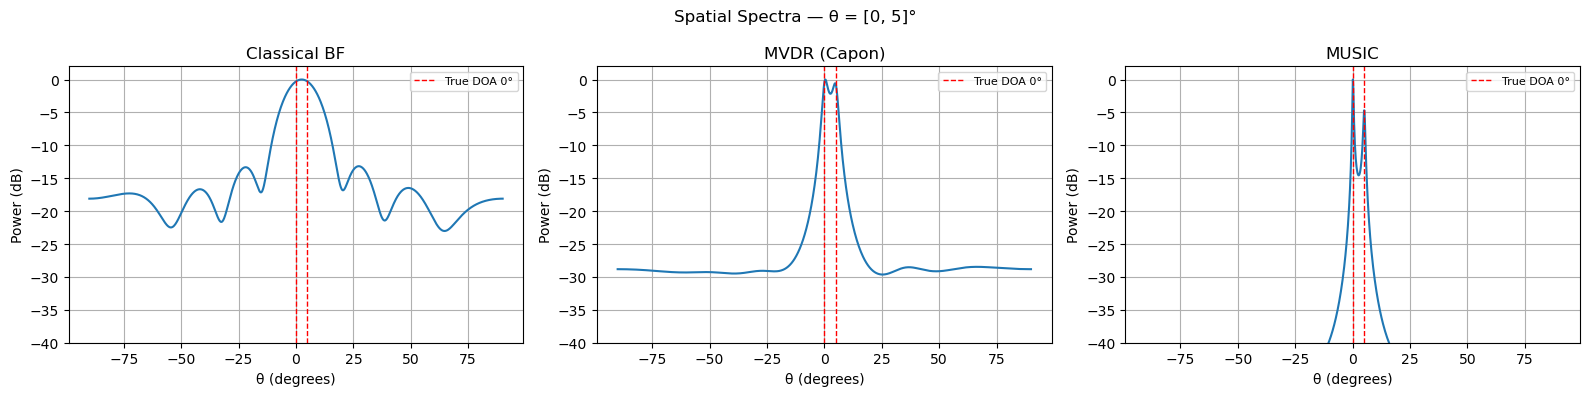

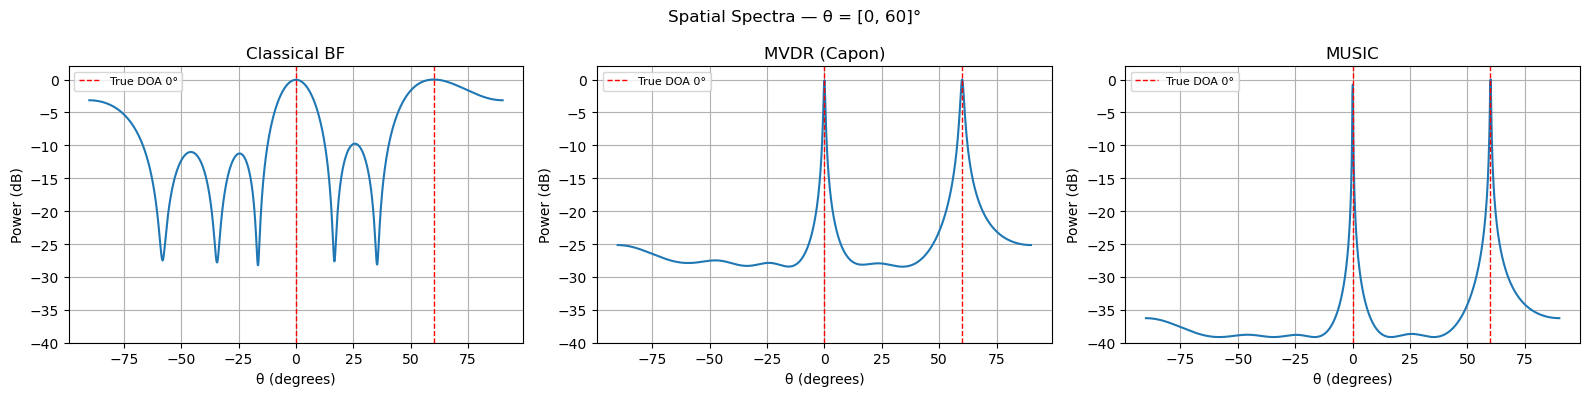

In [9]:
# ── Q4 Code ─────────────────────────────────────────────────
theta_scan = np.linspace(-90, 90, 1000)
M, N, Delta, SNR_dB = 7, 100, 0.5, 20
d = 2   # number of sources

def compute_spatial_spectra(theta_sources, d=2):
    """
    Compute and plot CBF, MVDR, and MUSIC spectra.
    """
    X, A_true, S = gen_data(M, N, Delta, theta_sources, SNR_dB)

    # Sample covariance matrix
    R_hat = (X @ X.conj().T) / N   # shape (M, M)

    P_cbf   = np.zeros(len(theta_scan))
    P_mvdr  = np.zeros(len(theta_scan))
    P_music = np.zeros(len(theta_scan))

    # ── MUSIC: eigendecomposition ────────────────────────────
    # ---- YOUR CODE HERE ----
    eigenvalues, eigenvectors = np.linalg.eigh(R_hat)
    # eigh returns eigenvalues in ascending order;
    # noise eigenvectors = first (M-d) columns (smallest eigenvalues)
    E_n = eigenvectors[:, :M - d]       # (M, M-d) noise subspace
    P_n = E_n @ E_n.conj().T           # noise projection matrix (M, M)

    R_hat_inv = np.linalg.inv(R_hat)

    # ── Scan over angles ─────────────────────────────────────
    for i, theta in enumerate(theta_scan):
        a = gen_a(M, Delta, theta)   # (M, 1)

        # ---- YOUR CODE HERE ----
        P_cbf[i]   = np.real(a.conj().T @ R_hat     @ a)[0, 0]
        P_mvdr[i]  = np.real(1.0 / (a.conj().T @ R_hat_inv @ a)[0, 0])
        P_music[i] = np.real(1.0 / (a.conj().T @ P_n        @ a)[0, 0])
        # ---- END YOUR CODE ----

    # Normalise to dB (max = 0 dB)
    def to_dB(P):
        return 10 * np.log10(P / P.max() + 1e-30)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (name, P) in zip(axes, [('Classical BF', P_cbf),
                                     ('MVDR (Capon)', P_mvdr),
                                     ('MUSIC',        P_music)]):
        ax.plot(theta_scan, to_dB(P), lw=1.5)
        for th in theta_sources:
            ax.axvline(th, color='r', ls='--', lw=1, label=f'True DOA {th}°' if th == theta_sources[0] else '')
        ax.set_title(name); ax.set_xlabel('θ (degrees)'); ax.set_ylabel('Power (dB)')
        ax.set_ylim(-40, 2); ax.grid(True)
        ax.legend(fontsize=8)

    plt.suptitle(f'Spatial Spectra — θ = {theta_sources}°', fontsize=12)
    plt.tight_layout(); plt.show()


compute_spatial_spectra([0, 5],  d=2)
compute_spatial_spectra([0, 60], d=2)

### Q4 Written Answer

**Resolution comparison (θ = [0°, 5°]):**  
> *Which method can resolve the two closely-spaced sources? Explain why.*

**Resolution comparison (θ = [0°, 60°]):**  
> *How do the results change for well-separated sources?*

**MVDR vs. Classical BF:**  
> *What is the key advantage of MVDR over conventional beamforming?*

**MUSIC subspace principle:**  
> *Why does the MUSIC spectrum have sharp peaks at the true DOAs?*